# 🚚 **Entregables**

**No olvide duplicar esta notebook para poder editar: File->Save a copy in Drive**

En este laboratorio, no es necesario redactar un informe en un documento separado. Por favor, complete todas las actividades requeridas dentro de esta notebook de Google Colab. Recuerde que una notebook le permite ingresar elementos de texto de manera similar a un procesador de documentos. Una vez finalizadas las actividades propuestas, deberá entregar lo siguiente en la plataforma:

1. Un archivo PDF generado en Google Colab desde el menú "Archivo" -> "Imprimir".

2. El enlace público de Google Colab. Para ello, vaya al botón de compartir y cambie la configuración de compartición a "Cualquier persona con el enlace".

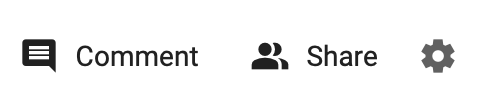

# 📔 **Resolución**
Una vez que la nota sea entregada, encontrarás la resolución en este link de notion:

https://www.notion.so/R-Churn-lab-classification-LogReg-with-and-without-GridSearchCV-154d05ccf4124959a2f7726d14dcd429?source=copy_link

Recuerda que existen varias formar de solucionar las actividades propuestas en los laboratorios. Toma la resolución entregada como referencia. En caso de que el link de resolución no esté público, solicita acceso en el mismo link de notion.|

# Predicción de pérdida de clientes en Empresas de Servicios de Telecomunicaciones (Churn)

Reducir las salidas y [deserciones de clientes](https://www.bain.com/insights/breaking-the-back-of-customer-churn/) se ha convertido en una alta prioridad para la mayoría de los proveedores de servicios de comunicaciones a medida que los mercados maduran y la competencia se intensifica.




En este documento usaremos una base de datos de una empresa de telecomunicaciones anónima [disponibilizada por IBM](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv).

El principal objetivo es crear un model de aprendizaje automático basado Regresión Logística (similar al propuesto [aquí con SVM](https://github.com/mmcuri/ds_handson/blob/master/Telecom_Churn_Prediction.ipynb)) para predecir la pérdida o salida de clientes en una empresa de telecomunicaciones.


## Librerías

Importamos varias bibliotecas y módulos útiles para el análisis de datos y el aprendizaje automático en Python. A continuación se describe cada uno de ellos:

- `pandas as pd`: Importa la biblioteca Pandas y la renombra como "pd". Pandas es una biblioteca popular utilizada para la manipulación y análisis de datos en Python.

- `numpy as np`: Importa la biblioteca NumPy y la renombra como "np". NumPy es una biblioteca de Python utilizada para realizar operaciones matemáticas en matrices y vectores.

- `matplotlib.pyplot as plt`: Importa la biblioteca Matplotlib y el módulo pyplot y lo renombra como "plt". Matplotlib es una biblioteca utilizada para la visualización de datos en Python.

- `from sklearn.metrics import classification_report`: Importa la función classification_report desde el módulo metrics de la biblioteca scikit-learn. classification_report es una función que calcula y muestra un informe de clasificación detallado para un modelo de clasificación.

- `from sklearn.metrics import confusion_matrix`: Importa la función confusion_matrix desde el módulo metrics de la biblioteca scikit-learn. confusion_matrix es una función que calcula y muestra la matriz de confusión para un modelo de clasificación.

- `from sklearn.metrics import accuracy_score`: Importa la función accuracy_score desde el módulo metrics de la biblioteca scikit-learn. accuracy_score es una función que calcula y muestra la precisión de un modelo de clasificación.

- `from sklearn.metrics import roc_auc_score`: Importa la función roc_auc_score desde el módulo metrics de la biblioteca scikit-learn. roc_auc_score es una función que calcula el área bajo la curva ROC (AUC) para un modelo de clasificación.

- `from sklearn.preprocessing import StandardScaler, LabelEncoder`: Importa las clases StandardScaler y LabelEncoder desde el módulo preprocessing de la biblioteca scikit-learn. StandardScaler es una clase utilizada para estandarizar los datos y LabelEncoder es una clase utilizada para codificar las etiquetas de clase en números enteros.

- `from sklearn.model_selection import train_test_split`: Importa la función train_test_split desde el módulo model_selection de la biblioteca scikit-learn. train_test_split es una función que divide los datos en conjuntos de entrenamiento y prueba para su uso en el modelado predictivo.

En resumen, este código importa varias bibliotecas y módulos que son útiles para el análisis de datos y el aprendizaje automático en Python.


In [1]:
# importing libraries
import pandas as pd #excel sofisticado
import numpy as np #matlab
import matplotlib.pyplot as plt #plots
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split


## Base de datos

Este conjunto de datos contiene un total de 7043 clientes y 21 características de los mismos. De las entradas, 5174 son clientes activos y 1869 son clientes que la empresa ha perdido. Observe que el conjunto de datos está desbalanceado pues por cada cliente perdido existe casi 3 clientes activos. La variable de salida para nuestro modelo de machine learning será `Churn`.

In [2]:
# importamos dataset
DATA_PATH = "https://raw.githubusercontent.com/mtgca/datasets_public/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA_PATH)
#print(df)
# vemos las primeras 5 filas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### *Detalles de la base de datos*

*	`customerID` - Custumer unique identifier
*	`gender` - Customer gender - ['Female' 'Male']
*	`SeniorCitizen` - Elderly or retired person, a senior citizen is someone who has at least attained the age of 60 of 65 years
*	`Partner` - - ['No' 'Yes']
*	`Dependents` - If customer has dependents - ['No' 'Yes']
*	`Tenure` - Customer lifespan (in months)
*	`PhoneService` - - ['No' 'Yes']
*	`MultipleLines` - - ['No' 'No phone service' 'Yes']
*	`InternetService` - - ['No' 'No internet service' 'Yes']
*	`OnlineSecurity` - - ['No' 'No internet service' 'Yes']
*	`OnlineBackup` - - ['No' 'No internet service' 'Yes']
*	`DeviceProtection` - - ['No' 'No internet service' 'Yes']
*	`TechSupport` - - ['No' 'No internet service' 'Yes']
*	`StreamingTV` - - ['No' 'No internet service' 'Yes']
*	`StreamingMovies` -  - ['No' 'No internet service' 'Yes']
*	`Contract` - Type of contract - ['Month-to-month' 'One year' 'Two year']
*	`PaperlessBilling` - - ['No' 'Yes']
*	`PaymentMethod` - payment method - ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
*	`MonthlyCharges` - Monthly Recurring Charges
*	`TotalCharges` - Life time value
*	`Churn` - Churn value, the targer vector - ['No' 'Yes']





### *Limpieza del Dataset*

El código presenta una serie de operaciones de preprocesamiento de datos en una base de datos que contiene información sobre clientes de una compañía, incluyendo su género, edad, servicios contratados, pagos realizados, entre otros.

En primer lugar, se define la función get_df_size para imprimir el número de atributos y entradas de la base de datos.

Luego, se reemplazan los valores en blanco por NaN para facilitar el manejo de valores faltantes en la base de datos.

A continuación, se reemplazan los valores faltantes en la columna 'TotalCharges' por la mediana de esa columna y se convierte esa columna al tipo numérico.

Después, se elimina la columna 'customerID' ya que no es una característica relevante.

A continuación, se codifican las características binarias en 0's y 1's usando LabelEncoder y se imprimen las categorías correspondientes a cada una de estas características.



**¿Por qué One-Hot Encoding?**

Cuando tenemos variables categóricas (por ejemplo, Color = {Rojo, Verde, Azul}), necesitamos convertirlas en valores numéricos para que los modelos puedan procesarlas. Hay dos enfoques comunes:

1. Label Encoding:
Asigna un número entero a cada categoría

(Rojo = 0, Verde = 1, Azul = 2).

El problema es que el modelo interpreta estos valores como si hubiera una relación de orden —por ejemplo, que Azul > Verde > Rojo—, algo que no tiene sentido en variables nominales. Esto introduce una falsa relación ordinal entre categorías.

2. One-Hot Encoding:
Crea una columna binaria para cada categoría. Por ejemplo:

Rojo → (1, 0, 0), Verde → (0, 1, 0), Azul → (0, 0, 1).

Así, cada categoría se representa como un vector independiente, sin orden ni jerarquía.

En la figura:

* A la izquierda (Label Encoding), las categorías están sobre una línea, implicando un orden.

* A la derecha (One-Hot Encoding), cada categoría ocupa un eje distinto, mostrando independencia.

👉 Implicación:
El one-hot encoding evita que el modelo asuma relaciones inexistentes y garantiza un tratamiento justo entre categorías puramente nominales.

⚠️ Desventajas del One-Hot Encoding:
* Incrementa la dimensionalidad del dataset (una columna por categoría).
* Puede generar matrices muy dispersas (muchos ceros).
* Es menos eficiente para variables con muchas categorías (“high cardinality”).
* Puede aumentar el tiempo de entrenamiento y el uso de memoria en modelos grandes.

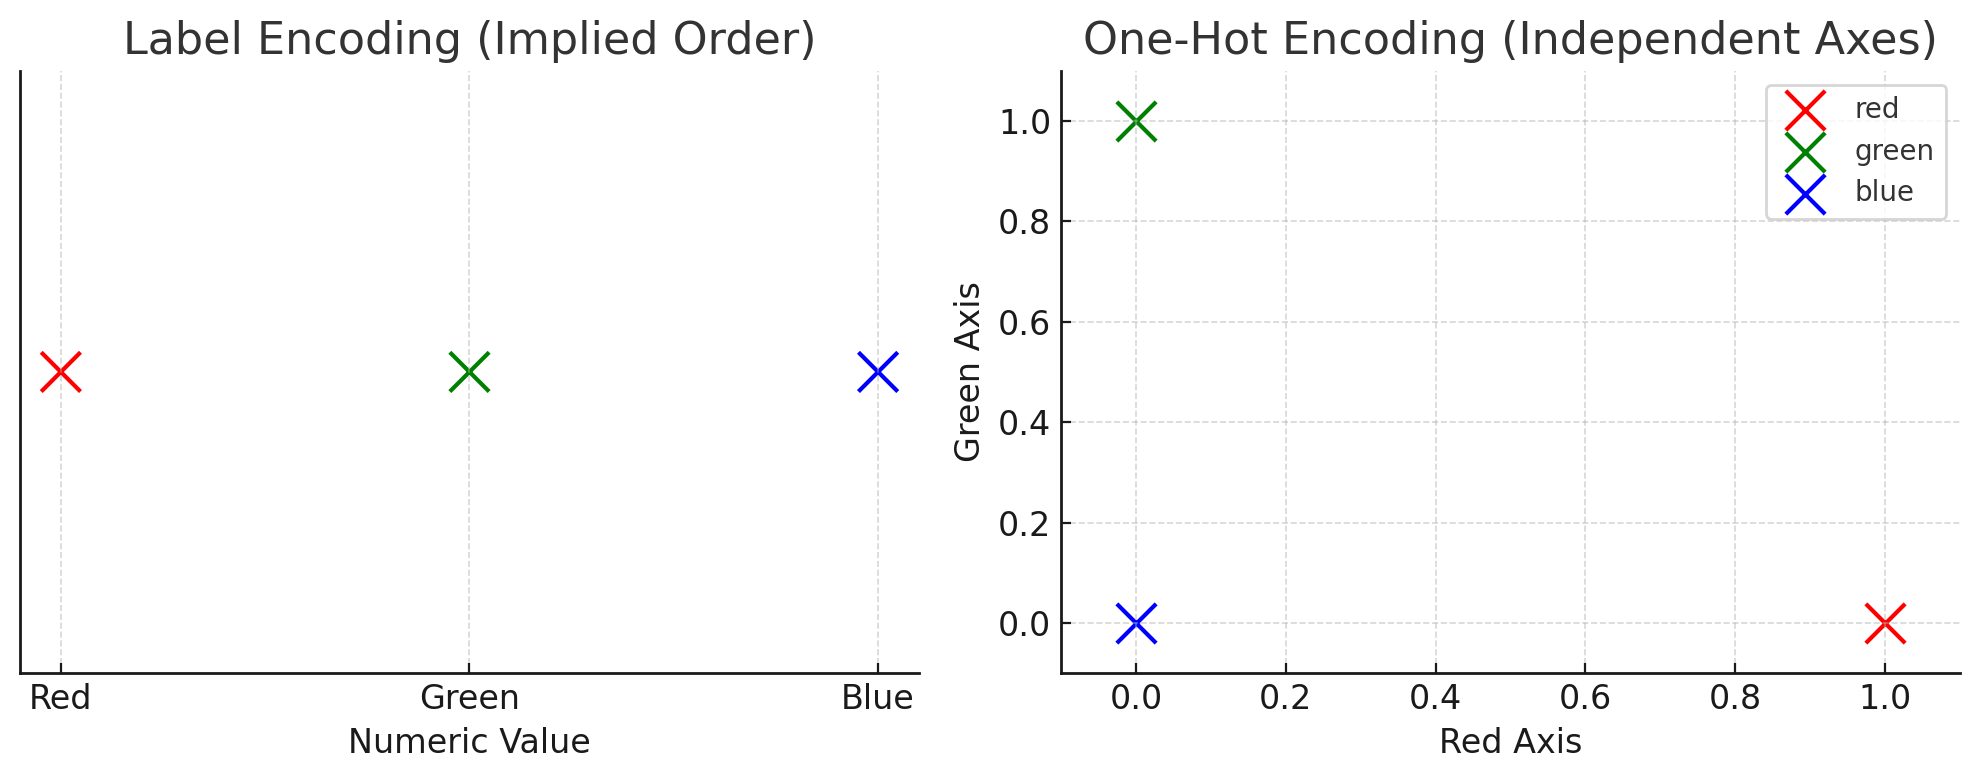

In [3]:
def get_df_size(df, header='Dataset dimensions'):
  print(header,
        '\n# Attributes: ', df.shape[1],
        '\n# Entries: ', df.shape[0],'\n')

get_df_size(df)

#df.info()

# reemplaza valores en blanco por NaN
df_clean = df.replace(r'^\s*$', np.nan, regex=True)

# Convert 'TotalCharges' to numeric before calculating the median.
# errors='coerce' will handle any non-numeric values by setting them to NaN.
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# reemplaza valores faltantes en TotalCharges por la mediana de TotalCharges.
total_charges_median = df_clean.TotalCharges.median()
df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)
df_clean['TotalCharges'] = df_clean['TotalCharges'].apply(pd.to_numeric)

#CustomerID lo retiramos porque no es una característica
df_clean = df_clean.drop('customerID', axis=1)
df_clean.describe()

print("Churn No Instances: ", df_clean[df_clean['Churn'] == 'No'].shape[0])
print("Churn Yes Instances: ", df_clean[df_clean['Churn'] == 'Yes'].shape[0])

binary_feat = df_clean.nunique()[df_clean.nunique() == 2].keys().tolist()
numeric_feat = [col for col in df_clean.select_dtypes(['float','int']).columns.tolist() if col not in binary_feat]
categorical_feat = [ col for col in df_clean.select_dtypes('object').columns.to_list() if col not in binary_feat + numeric_feat ]
df_proc = df_clean.copy()
#Etiquetas para características binarias
le = LabelEncoder()
for i in binary_feat:
  df_proc[i] = le.fit_transform(df_proc[i])
  print(i, '\n', np.unique(df_proc[i].values))
#Dummy variables
df_proc = pd.get_dummies(df_proc, columns=categorical_feat)
get_df_size(df, header='Original dataset:')
get_df_size(df_proc, header='Processed dataset:')
df_proc.head()


Dataset dimensions 
# Attributes:  21 
# Entries:  7043 

Churn No Instances:  5174
Churn Yes Instances:  1869
gender 
 [0 1]
SeniorCitizen 
 [0 1]
Partner 
 [0 1]
Dependents 
 [0 1]
PhoneService 
 [0 1]
PaperlessBilling 
 [0 1]
Churn 
 [0 1]
Original dataset: 
# Attributes:  21 
# Entries:  7043 

Processed dataset: 
# Attributes:  41 
# Entries:  7043 



/tmp/ipykernel_3344/2470922283.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['TotalCharges'].fillna(total_charges_median, inplace=True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,True,False,False,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,True,False,False,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,True,False,True,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,True,False,False,True,False,False,False,False,True,False


### *División en conjunto de entrenamiento y test*

En el código, se divide el conjunto de datos df_proc en características y variable objetivo X e y, respectivamente. Luego, se realiza una división de los datos en conjuntos de entrenamiento y prueba utilizando la función train_test_split de scikit-learn. Los conjuntos de entrenamiento y prueba se almacenan en X_train, X_test, y_train y y_test. La división se realiza de manera estratificada para asegurar que la proporción de instancias positivas y negativas en la variable objetivo se mantenga en ambos conjuntos. Se utiliza una proporción de 80/20 para los conjuntos de entrenamiento y prueba, respectivamente, y se fija una semilla aleatoria (random_state) en 42 para asegurar que los resultados sean reproducibles.

In [4]:
# dividimos df_proc en características y salida
X=df_proc.drop('Churn', axis=1)
y=df_proc['Churn']

# Dividimos el conjunto de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

### *Balanceo de datos*

Este código realiza el submuestreo (undersampling) de un conjunto de datos desbalanceado en términos de la variable objetivo. El submuestreo se utiliza para abordar el problema del desequilibrio de clases en el conjunto de datos, donde una o varias clases tienen muchas menos observaciones que las otras clases. En este caso, el modelo de aprendizaje automático puede estar sesgado hacia la clase mayoritaria, lo que puede resultar en un rendimiento deficiente en la clasificación de la clase minoritaria.

El submuestreo implica reducir el número de observaciones en la clase mayoritaria para equilibrar la distribución de las clases en el conjunto de datos. Esto puede mejorar el rendimiento del modelo en la clasificación de la clase minoritaria y reducir el sesgo hacia la clase mayoritaria.

La biblioteca imblearn se utiliza para realizar el submuestreo, y en este caso se importa la clase RandomUnderSampler. El objeto RandomUnderSampler se inicializa con random_state=1, lo que garantiza que los resultados serán reproducibles.

Luego, el submuestreo se realiza en el conjunto de entrenamiento (X_train, y_train) mediante el método fit_resample del objeto rus. Los datos submuestreados se almacenan en X_train_rus y y_train_rus.

Para evaluar el efecto del submuestreo, se utiliza la función get_df_size, que devuelve el tamaño del conjunto de datos. Primero se imprime el tamaño del conjunto de entrenamiento original (X_train, y_train) antes del submuestreo, y luego se imprime el tamaño del conjunto submuestreado (X_train_rus, y_train_rus) después de aplicar el submuestreo.

Finalmente, se utiliza la función np.unique para verificar que las categorías de la variable objetivo (y_train_rus) estén balanceadas. La función devuelve una tupla que contiene las categorías únicas y el número de instancias en cada categoría. Al utilizar return_counts=True, se garantiza que se devuelvan los recuentos de las categorías.

In [5]:
# submuestreo -> under sampling
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=1)
X_train_undersampled, y_train_undersampled = rus.fit_resample(X_train, y_train)
get_df_size(X_train, header='Before balancing:')
get_df_size(X_train_undersampled, header='After balancing:')

# verificamos que las categorias estén balanceadas
np.unique(y_train_undersampled, return_counts=True)


Before balancing: 
# Attributes:  40 
# Entries:  5634 

After balancing: 
# Attributes:  40 
# Entries:  2990 



(array([0, 1]), array([1495, 1495]))

## Modelo de Machine Learning

Este código construye un modelo de regresión logística para un conjunto de datos y lo evalúa en un conjunto de datos de prueba y de entrenamiento.

Primero, se define una tubería (pipeline) que encadena tres pasos:

PolynomialFeatures(degree=2): Crea una matriz de características polinómicas de grado 2 a partir de las características originales.
StandardScaler(): Estandariza las características.
LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value): Ajusta un modelo de regresión logística a los datos, utilizando una regularización L2 (Ridge) y un parámetro de regularización C inversamente proporcional a lambda_value.
Luego, el modelo se entrena en un conjunto de datos de entrenamiento (X_train_undersampled e y_train_undersampled) utilizando el método fit.

A continuación, el modelo se evalúa en un conjunto de datos de prueba (X_test e y_test). Las predicciones se obtienen con el método predict y se calcula la precisión (accuracy) utilizando metrics.accuracy_score. La precisión en el conjunto de datos de prueba se almacena en la variable acc_test y se imprime en pantalla.

Finalmente, se evalúa el modelo en el conjunto de datos de entrenamiento (X_train_undersampled e y_train_undersampled) y se almacena la precisión en la variable acc_train, que también se imprime en pantalla.

## ✅ Actividad 1

El objetivo de esta actividad es generar un gráfico donde el eje X represente el hiperparámetro de regularización lambda (`lambda_value`) y el eje Y muestre el **recall**. El recall es una métrica entre 0 y 1, donde 1 indica el mejor rendimiento (0% falsos negativos).

El gráfico deberá incluir el recall tanto para el conjunto de entrenamiento como para el conjunto de validación. Utilice los siguientes valores de lambda para el eje X: `[1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1e3, 1e4]`. Configure el eje X con una escala logarítmica para una mejor visualización.

A partir del gráfico, identifique el valor óptimo de lambda. Para ello, utilice GridSearchCV con k=5 folds.

Finalmente, evalúe el modelo optimizado (es decir, aquel con el `lambda_value` que mostró el mejor rendimiento en el conjunto de validación) en el conjunto de prueba, reportando tanto el accuracy como el recall. Tenga en cuenta que esta actividad podría **tardar en ejecutarse**.

¿Por qué considera que el recall es una métrica más adecuada para este problema? Analice la importancia de reducir los falsos negativos en la predicción de churn.


### **Opcional: Optimización Bayesiana  Optimización Bayesiana de Hiperparámetros**

La optimización bayesiana de hiperparámetros es un método avanzado para seleccionar los mejores hiperparámetros para un modelo de aprendizaje automático. A diferencia de la búsqueda en cuadrícula (**Grid Search**) y la búsqueda aleatoria (**Random Search**), que evalúan combinaciones de hiperparámetros sin considerar los resultados previos, la optimización bayesiana utiliza la información obtenida en iteraciones anteriores para decidir qué configuraciones explorar posteriormente.

Este enfoque construye un modelo probabilístico de la función objetivo (por ejemplo, la precisión de validación) y emplea dicho modelo para estimar qué regiones del espacio de búsqueda tienen mayor probabilidad de contener mejores soluciones. De esta manera, se reduce significativamente el número de evaluaciones necesarias para encontrar configuraciones de alto desempeño.

Las principales ventajas de la optimización bayesiana incluyen:

* Mayor eficiencia, al requerir menos evaluaciones que Grid Search o Random Search.
* Mejor desempeño, al concentrar la búsqueda en regiones prometedoras del espacio de hiperparámetros.
* Flexibilidad, permitiendo optimizar espacios de búsqueda complejos con variables continuas, discretas y categóricas.

**Herramientas recomendadas**

Existen varias bibliotecas para realizar optimización bayesiana en Python:

* **scikit-optimize (skopt)**: biblioteca integrada con el ecosistema de scikit-learn que proporciona la clase BayesSearchCV, similar a GridSearchCV y RandomizedSearchCV.
* **Optuna**: framework moderno para optimización automática de hiperparámetros. Utiliza por defecto el algoritmo TPE (Tree-structured Parzen Estimator), un método de optimización bayesiana eficiente para espacios de búsqueda complejos. Optuna es ampliamente utilizado tanto en investigación como en aplicaciones industriales debido a su facilidad de uso y capacidad para realizar pruning (detención temprana de experimentos poco prometedores).

**Recursos**

* Optuna: https://optuna.org/
* Scikit-Optimize: https://scikit-optimize.github.io/
* Tutorial de Scikit-Optimize: https://machinelearningmastery.com/scikit-optimize-for-hyperparameter-tuning-in-machine-learning/



In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
import sklearn.metrics as metrics

lambda_value = 1
model_logreg =  Pipeline([
                ('polynomial_features', PolynomialFeatures(degree=2)), #no cambiar
                ('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression(max_iter=20000, penalty='l2', C=1/lambda_value))
 ])

# training
model_logreg.fit(X_train_undersampled, y_train_undersampled)

# evaluation on test set
pred_test = model_logreg.predict(X_test)
acc_test = metrics.accuracy_score(y_test, pred_test)
print("Accuracy on test set Logistic Regression: ", acc_test)
# evaluation on training set
pred_train = model_logreg.predict(X_train_undersampled)
acc_train = metrics.accuracy_score(y_train_undersampled, pred_train)
print("Accuracy on training set Logistic Regression: ", acc_train)

Accuracy on test set Logistic Regression:  0.7331440738112136
Accuracy on training set Logistic Regression:  0.7966555183946489


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix

# Funciones para evaluar, graficar y reutilizar en todas las actividades

def evaluate_model(model, X_eval, y_eval, name="Model"):
    pred = model.predict(X_eval)
    metrics_dict = {
        "recall": recall_score(y_eval, pred),
        "accuracy": accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred),
        "f1": f1_score(y_eval, pred),
        "confusion_matrix": confusion_matrix(y_eval, pred)
    }

    print(f"\n{name}")
    print(f"Recall:    {metrics_dict['recall']:.4f}")
    print(f"Accuracy:  {metrics_dict['accuracy']:.4f}")
    print(f"Precision: {metrics_dict['precision']:.4f}")
    print(f"F1:        {metrics_dict['f1']:.4f}")
    print("Confusion Matrix:")
    print(metrics_dict["confusion_matrix"])

    return metrics_dict

def grid_search_evaluate(model, param_grid, X_train, y_train, X_test, y_test, name="Model", cv=5, refit='recall'):
    grid_search = GridSearchCV(
        estimator=model, 
        param_grid=param_grid, 
        scoring={
        'recall': 'recall',
        'accuracy': 'accuracy',
        'precision': 'precision',
        'f1': 'f1'
        }, 
        refit=refit,
        cv=cv,
        return_train_score=True,
        n_jobs=-1,
        verbose=6
    )
    grid_search.fit(X_train, y_train)

    cv_results = pd.DataFrame(grid_search.cv_results_)
    cv_results['lambda_value'] = 1 / cv_results['param_logistic_regression__C'].astype(float)
    cv_results = cv_results.sort_values('lambda_value')

    best_model = grid_search.best_estimator_
    best_lambda = 1 / grid_search.best_params_['logistic_regression__C']

    print(f"\n{name} on Validation:")
    print(f"Best lambda: {best_lambda:g}")
    print(f"Recall:      {grid_search.best_score_:.4f}")
    print(f"Accuracy:    {cv_results.loc[cv_results['lambda_value'] == best_lambda, 'mean_test_accuracy'].values[0]:.4f}")
    print(f"Precision:   {cv_results.loc[cv_results['lambda_value'] == best_lambda, 'mean_test_precision'].values[0]:.4f}")
    print(f"F1:          {cv_results.loc[cv_results['lambda_value'] == best_lambda, 'mean_test_f1'].values[0]:.4f}")

    metrics_dict = evaluate_model(best_model, X_test, y_test, name=name + " on Test Set:")
    
    return best_model, cv_results, metrics_dict

def plot_cv_results(cv_results):
    metrics_to_plot = ['recall', 'accuracy', 'precision', 'f1']

    summary_plot = cv_results[['lambda_value'] + [f'mean_train_{m}' for m in metrics_to_plot] + [f'mean_test_{m}' for m in metrics_to_plot]].copy()
    summary_plot = summary_plot.sort_values('lambda_value')

    best_idx = summary_plot['mean_test_recall'].idxmax()
    best_lambda = summary_plot.loc[best_idx, 'lambda_value']

    fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
    axes = axes.ravel()

    for ax, m in zip(axes, metrics_to_plot):
        ax.plot(summary_plot['lambda_value'], summary_plot[f'mean_train_{m}'], marker='o', label='Train (CV)')
        ax.plot(summary_plot['lambda_value'], summary_plot[f'mean_test_{m}'], marker='s', label='Validation (CV)')
        ax.axvline(best_lambda, color='black', linestyle='--', label=f'Best λ={best_lambda:g}')
        ax.set_xscale('log')
        ax.set_xlabel('Lambda')
        ax.set_ylabel(m.capitalize())
        ax.set_title(f'{m.capitalize()}')
        ax.grid(True)
        ax.legend()

    plt.tight_layout()
    plt.show()

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Actividad 1 - Undersampling on Validation:
Best lambda: 10000
Recall:      0.8067
Accuracy:    0.7602
Precision:   0.7386
F1:          0.7710

Actividad 1 - Undersampling on Test Set:
Recall:    0.7968
Accuracy:  0.7317
Precision: 0.4967
F1:        0.6119
Confusion Matrix:
[[733 302]
 [ 76 298]]


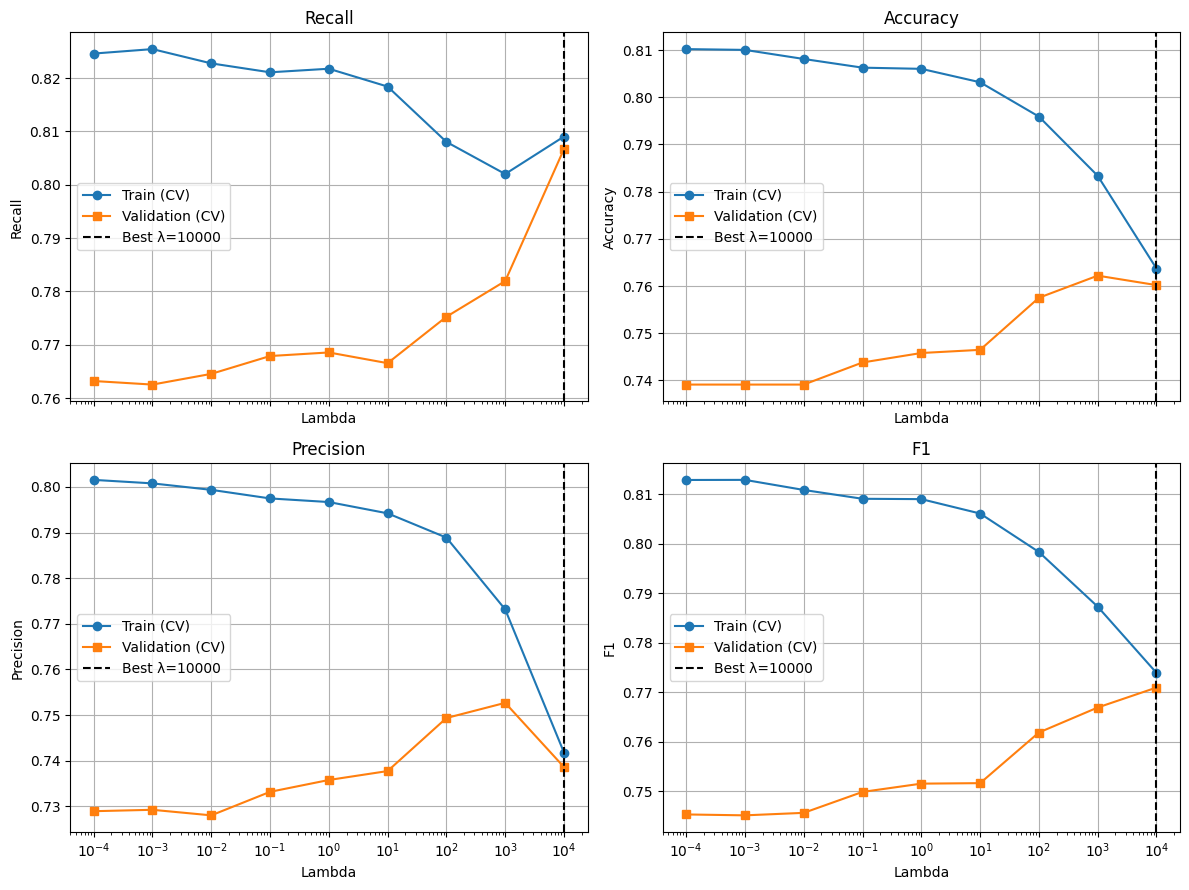

In [8]:
lambda_values = np.array([1e-4, 1e-3, 1e-2, 0.1, 1, 10, 100, 1e3, 1e4])

model_logreg_cv = Pipeline([
    ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(max_iter=20000, penalty='l2'))
])

param_grid = {
    'logistic_regression__C': 1 / lambda_values
}

best_model_a1, cv_results_a1, metrics_dict_a1 = grid_search_evaluate(
    model=model_logreg_cv,
    param_grid=param_grid,
    X_train=X_train_undersampled,
    y_train=y_train_undersampled,
    X_test=X_test,
    y_test=y_test,
    name="Actividad 1 - Undersampling",
    cv=5,
    refit='recall'
)

results = {}
results['Actividad 1 - Undersampling'] = metrics_dict_a1

plot_cv_results(cv_results_a1)

Fitting 5 folds for each of 7 candidates, totalling 35 fits

Actividad 1 - Undersampling + Big Lambda Value on Validation:
Best lambda: 1e+07
Recall:      0.8482
Accuracy:    0.7505
Precision:   0.7100
F1:          0.7728

Actividad 1 - Undersampling + Big Lambda Value on Test Set:
Recall:    0.8262
Accuracy:  0.6884
Precision: 0.4524
F1:        0.5847
Confusion Matrix:
[[661 374]
 [ 65 309]]


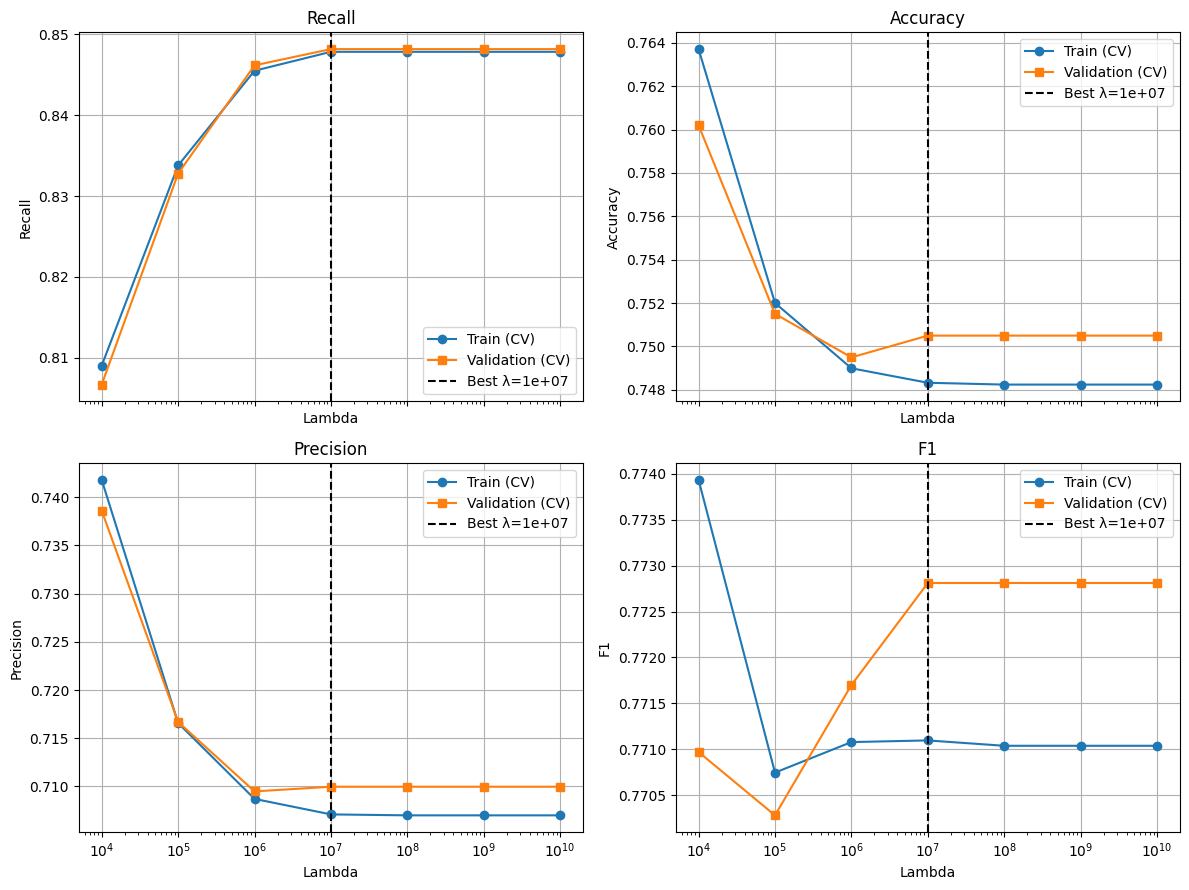

In [9]:
# Volvemos a probar con valores de lambda más grandes

lambda_values_2 = np.array([1e4, 1e5, 1e6, 1e7, 1e8, 1e9, 1e10])

param_grid_2 = {
    'logistic_regression__C': 1 / lambda_values_2
}

best_model_a1_2, cv_results_a1_2, metrics_dict_a1_2 = grid_search_evaluate(
    model=model_logreg_cv,
    param_grid=param_grid_2,
    X_train=X_train_undersampled,
    y_train=y_train_undersampled,
    X_test=X_test,
    y_test=y_test,
    name="Actividad 1 - Undersampling + Big Lambda Value",
    cv=5,
    refit='recall'
)

results['Actividad 1 - Undersampling + Big Lambda Value'] = metrics_dict_a1_2

plot_cv_results(cv_results_a1_2)

### Conclusión

En esta actividad se utilizó recall como métrica principal debido a que el objetivo del problema es identificar la mayor cantidad posible de clientes que abandonarán el servicio. En un escenario de churn, no detectar a un cliente que efectivamente abandonará (falso negativo) suele ser más costoso para la empresa que contactar a un cliente que finalmente no abandona (falso positivo).

La búsqueda de hiperparámetros mostró una tendencia consistente hacia valores muy altos de regularización ($\lambda = 10^4$ y posteriormente $\lambda = 10^7$), lo que sugiere que optimizar únicamente el recall favorece modelos cada vez más simples. Aunque el recall mejora ligeramente, se observa una disminución en accuracy, precision y F1-score, indicando un incremento de falsos positivos y un posible problema de subajuste.

Este comportamiento puede estar relacionado tanto con el criterio de optimización elegido como con el uso de Random Under Sampling, que reduce significativamente la cantidad de datos disponibles para entrenar el modelo. En consecuencia, una regularización extrema termina siendo competitiva en validación, aunque no necesariamente representa el mejor equilibrio entre capacidad predictiva y generalización.

## ✅ Actividad 2 Tratamiento del Desbalance de Clases mediante SMOTE y Pesos de Clase

Implemente un pipeline de scikit-learn que aborde el desbalance de clases utilizando dos técnicas simultáneamente:

1. **Sobremuestreo (Oversampling)**: Aplique la técnica SMOTE (`imblearn.over_sampling.SMOTE`) para sintéticamente generar muestras de la clase minoritaria.

2. **Pesos de Clase (Class Weights)**: Calcule y asigne pesos de clase (`sklearn.utils.class_weight.compute_class_weight`) al modelo de Regresión Logística para penalizar errores en la clase minoritaria.

Para esta actividad, utilice el conjunto de datos completo y original (es decir, **sin aplicar el undersampling** realizado en la Actividad 1).

Evalúe el rendimiento del modelo resultante (accuracy) en el conjunto de prueba y compárelo con los resultados obtenidos en la Actividad 1 (que utilizó undersampling).


**Recursos:**

https://machinelearningmastery.com/smote-oversampling-for-imbalanced-classification/

https://imbalanced-learn.org/stable/references/generated/imblearn.over_sampling.SMOTE.html



Fitting 5 folds for each of 9 candidates, totalling 45 fits

Actividad 2 - SMOTE + class weights on Validation:
Best lambda: 10000
Recall:      0.9358
Accuracy:    0.6196
Precision:   0.4061
F1:          0.5664

Actividad 2 - SMOTE + class weights on Test Set:
Recall:    0.9385
Accuracy:  0.6153
Precision: 0.4034
F1:        0.5643
Confusion Matrix:
[[516 519]
 [ 23 351]]


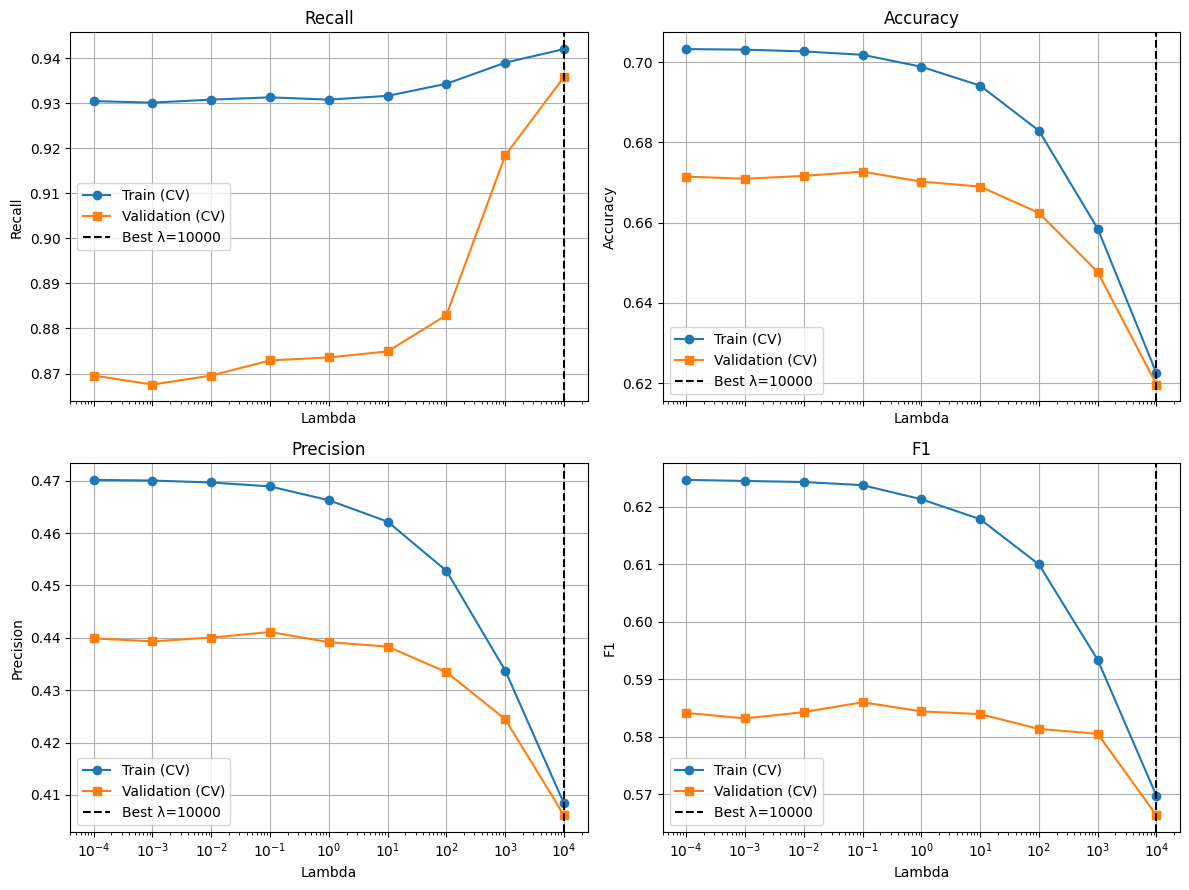

In [10]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

model_a2_cv = ImbPipeline([
    ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('logistic_regression', LogisticRegression(
        max_iter=20000,
        penalty='l2',
        class_weight=class_weights
    ))
])

best_model_a2, cv_results_a2, metrics_dict_a2 = grid_search_evaluate(
    model=model_a2_cv,
    param_grid=param_grid,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    name="Actividad 2 - SMOTE + class weights",
    cv=5,
    refit='recall'
)

results['Actividad 2 - SMOTE + class weights'] = metrics_dict_a2

plot_cv_results(cv_results_a2)

### Conclusión

La combinación de SMOTE y pesos de clase incrementó significativamente el recall, alcanzando valores cercanos a 0.94 tanto en validación como en test. Esto significa que el modelo logra identificar la gran mayoría de los clientes que abandonarán el servicio, reduciendo considerablemente la cantidad de falsos negativos.

Sin embargo, esta mejora viene acompañada de una fuerte disminución en accuracy, precision y F1-score. La matriz de confusión muestra un aumento considerable de falsos positivos, lo que indica que el modelo clasifica como churn a muchos clientes que en realidad no abandonan el servicio.

Al igual que en la Actividad 1, el mejor valor de regularización vuelve a ubicarse en el extremo superior del rango evaluado ($\lambda = 10^4$), lo que refuerza la idea de que optimizar exclusivamente recall favorece modelos que priorizan detectar la mayor cantidad posible de casos positivos, incluso a costa de cometer más errores sobre la clase negativa. Por lo tanto, aunque esta estrategia maximiza la detección de churn, puede generar campañas de retención menos eficientes debido al elevado número de falsas alarmas.

## ✅ Actividad 3: Combinando SMOTE, Pesos de Clase y PCA

Replique el enfoque de la Actividad 2 (utilizando SMOTE para sobremuestreo y pesos de clase para manejar el desbalance, sin undersampling), pero ahora **integrando PCA** en el pipeline.

El orden de los pasos en el pipeline es:

1.  `PolynomialFeatures`
2.  `StandardScaler`
3.  `PCA` (95%)
4.  `LogisticRegression` (con pesos de clase)

Utilice el mismo conjunto de datos completo y original que en la Actividad 2.

Evalúe el rendimiento del modelo resultante (accuracy, recall, y si lo desea, otras métricas relevantes) en el conjunto de prueba y compare los resultados con los obtenidos en las actividades anteriores.

¿Cómo afecta la reducción de dimensionalidad con PCA, en conjunto con SMOTE y pesos de clase, al rendimiento del modelo?

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Actividad 3 - SMOTE + class weights + PCA on Validation:
Best lambda: 10000
Recall:      0.9351
Accuracy:    0.6164
Precision:   0.4039
F1:          0.5641

Actividad 3 - SMOTE + class weights + PCA on Test Set:
Recall:    0.9439
Accuracy:  0.6132
Precision: 0.4025
F1:        0.5643
Confusion Matrix:
[[511 524]
 [ 21 353]]


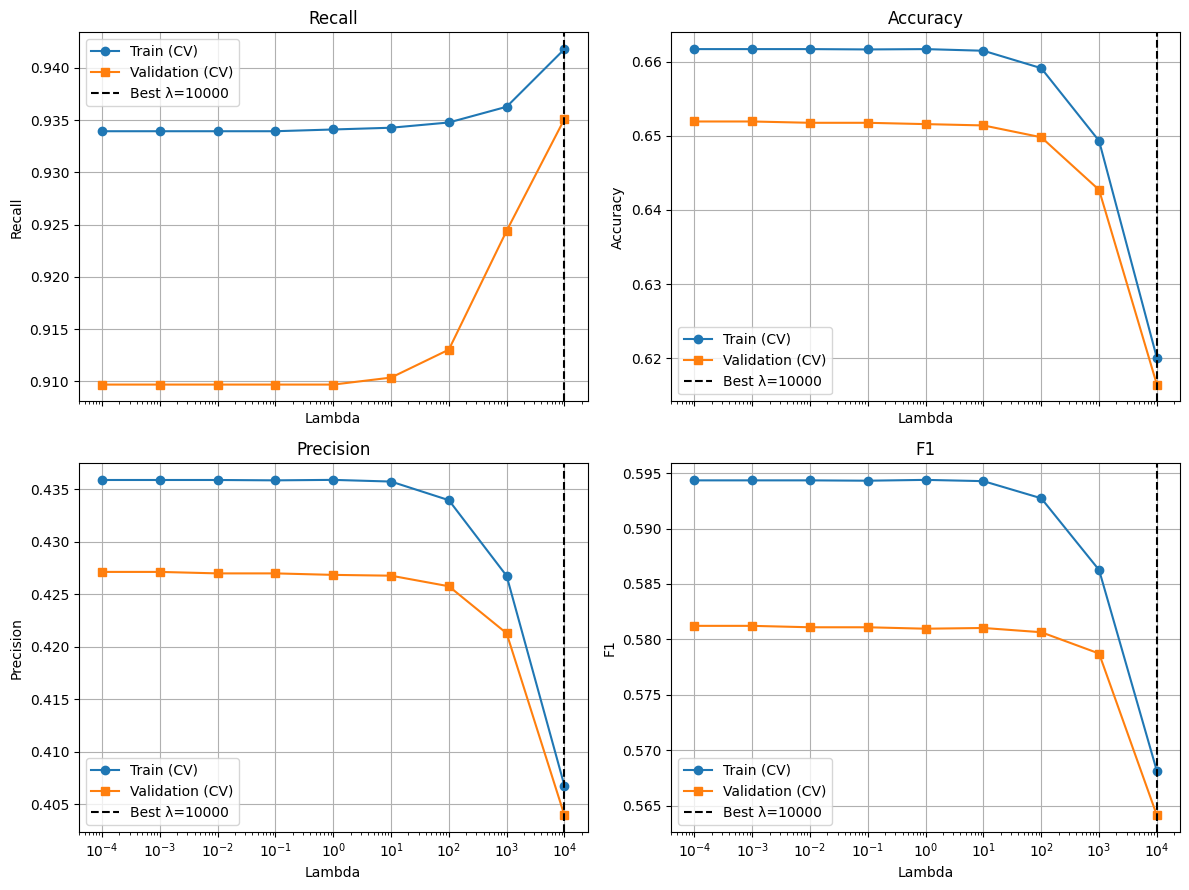

In [11]:
from sklearn.decomposition import PCA

model_a3_cv = ImbPipeline([
    ('polynomial_features', PolynomialFeatures(degree=2)),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('smote', SMOTE(random_state=42)),
    ('logistic_regression', LogisticRegression(
        max_iter=20000,
        penalty='l2',
        class_weight=class_weights
    ))
])

best_model_a3, cv_results_a3, metrics_dict_a3 = grid_search_evaluate(
    model=model_a3_cv,
    param_grid=param_grid,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    name="Actividad 3 - SMOTE + class weights + PCA",
    cv=5,
    refit='recall'
)

results['Actividad 3 - SMOTE + class weights + PCA'] = metrics_dict_a3

plot_cv_results(cv_results_a3)

### Conclusión

La incorporación de PCA no produjo cambios relevantes en el desempeño del modelo. Las métricas obtenidas son prácticamente idénticas a las de la Actividad 2, manteniendo un recall cercano a 0.94 y valores similares de accuracy, precision y F1-score.

Esto sugiere que la reducción de dimensionalidad no aportó información adicional ni eliminó ruido de manera significativa para este problema. En otras palabras, la representación obtenida tras la expansión polinómica ya contenía la información necesaria para que la regresión logística alcanzara su desempeño máximo bajo el criterio de optimización utilizado.

Aunque PCA puede ser útil para reducir la complejidad computacional o facilitar la interpretación en escenarios de alta dimensionalidad, en este caso no se observan mejoras predictivas que justifiquen su incorporación desde el punto de vista del desempeño del modelo.

In [12]:
comparison = pd.DataFrame(results).T
print("\nComparison of Models:")
display(comparison)


Comparison of Models:


,recall,accuracy,precision,f1,confusion_matrix
Actividad 1 - Undersampling,0.796791,0.731725,0.496667,0.61191,"[[733, 302], [76, 298]]"
Actividad 1 - Undersampling + Big Lambda Value,0.826203,0.688432,0.452416,0.584674,"[[661, 374], [65, 309]]"
Actividad 2 - SMOTE + class weights,0.938503,0.61533,0.403448,0.564309,"[[516, 519], [23, 351]]"
Actividad 3 - SMOTE + class weights + PCA,0.94385,0.613201,0.402509,0.564349,"[[511, 524], [21, 353]]"


# ✅ Conclusiones Finales

El objetivo principal de este laboratorio fue construir un modelo capaz de identificar clientes con riesgo de abandono, utilizando recall como métrica principal debido a que los falsos negativos representan el costo más importante para el negocio.

Los resultados muestran un claro compromiso entre recall y precision. Mientras que la estrategia basada en undersampling alcanzó un recall cercano a 0.80 con una precisión moderada, las estrategias basadas en SMOTE y pesos de clase elevaron el recall hasta aproximadamente 0.94, pero a costa de duplicar prácticamente la cantidad de falsos positivos y reducir significativamente la precisión.

Además, en todas las actividades el mejor valor de regularización se ubicó en el límite superior del rango evaluado, lo que sugiere que el criterio de optimización basado únicamente en recall favorece modelos altamente regularizados y potencialmente subajustados. Esto evidencia la importancia de complementar el análisis con métricas como precision o F1-score para obtener una evaluación más equilibrada.

Considerando los resultados obtenidos, la mejor estrategia dependerá del objetivo del negocio. Si la prioridad absoluta es no perder clientes con riesgo de churn, las estrategias de las Actividades 2 y 3 resultan más adecuadas debido a su elevado recall. Sin embargo, si también se busca controlar la cantidad de intervenciones innecesarias sobre clientes que no abandonarán el servicio, la solución de la Actividad 1 ofrece un balance más razonable entre detección y precisión.

Asimismo, los resultados reflejan el fuerte desbalance presente en el dataset de churn. Este desbalance explica por qué técnicas como undersampling, SMOTE y class weights tienen un impacto tan significativo sobre el comportamiento del modelo y por qué métricas como accuracy pueden resultar engañosas al evaluar el desempeño. En este contexto, métricas enfocadas en la clase minoritaria, como recall y F1-score, proporcionan una evaluación más representativa de la capacidad real del modelo para detectar clientes con riesgo de abandono.
